In [27]:
# magics: ensures that any changes to the modules loaded below will be re-loaded automatically
%load_ext autoreload
%autoreload 2
%load_ext line_profiler

import os
import sys
#sys.path.append('/Users/jacobaspnissen/Desktop/Økonomi/Dynamic programming/Termpaper/termpaper_dynprog/Job Search/')
#sys.path.append('/Users/albertolsen/Documents/Stud Polit/9. semester/Dynamic Programming/Exam/termpaper_dynprog/Job Search')
import Model_components_J as model
import numpy as np
from time import process_time
import matplotlib.pyplot as plt
from scipy import interpolate 
import optimagic as om
from matplotlib import cm
from matplotlib.ticker import LinearLocator
import pandas as pd
import scipy.optimize as opt
from scipy.optimize import fsolve
from scipy.stats import beta
from numba import njit, vectorize


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
The line_profiler extension is already loaded. To reload it, use:
  %reload_ext line_profiler


### Define Paramters and Institutions

In [28]:
delta = 0.89 # discount factor
gamma = 0.81 # Inverse elasticity of search effort with respect to net value of employment
eta = 1 # gain/loss parameter from difference in income relative to reference income
k = 159 # Search cost parameter
k1 = 300 # search cost parameter for type 1
k2 = 150 # search cost parameter for type 2
k3 = 90 # search cost parameter for type 3
q1 = 0.33 # share of type 1 in the population
q2 = 0.33 # share of type 2 in the population
lmbda = 4.9 # loss aversion
N = 6 # reference period

abar = [0, 20000] # size of asset grid

n_a = 100 # number of asset grid points
n_c = 100 # number of consumption grid points
T1 = 6 # end of first benefit period 
T2 = 18 # end of second benefit period
T3 = 24 # end of third benefit period
T = 44 # total number of periods
b1= 222 # benefit level 1
b2 = 222 # benefit level 2
b3 = 114 # benefit level 3
welfare = 90 # welfare level (after benefits expire)
w = 675 # wage level
R = 0.01 # interest rate

htm = 1 # hand to mouth indicator (1 if hand to mouth, 0 otherwise)




### Create arrays for parameters
institutions pre are the institutions with 2 shifts

In [29]:
params_rd = np.array([delta, gamma, eta, k, lmbda, N])

eta = 0
lmbda = 0
params_st = np.array([delta, gamma, eta, k, lmbda, N])
params_twotype = np.array([delta, gamma, eta, k1, lmbda, N, k2, q1])
params_multi = np.array([delta, gamma, eta, k1, lmbda, N, k2, k3, q1, q2])


institutions_pre = np.array([ n_a, n_c, T1, T2, T3, T, b1, b2, b3, welfare, w, R])

b1 = 342
b2 = 171
institutions_post = np.array([ n_a, n_c, T1, T2, T3, T, b1, b2, b3, welfare, w, R])



#### Weights/distribution of initial asset level
If htm = 1, hand to mouth consumption, everyone has zero assets from the beginning
if htm = 0, heterogenous initial assets

In [14]:
weights = model.make_weights(htm, abar, n_a)

In [15]:
weights

array([1.])

## Predict standard Model on Pre-reform institutions
First we predict using 1 types, then followed by 2 types and 3 types

In [34]:
S_std_pre, V_emp_std_pre, V_unemp_std_pre, c_emp_std_pre, c_unemp_std_pre, Vss_emp_std_pre, Vss_uemp_std_pre, css_emp_std_pre, css_uemp_std_pre, survival_std_pre, benefits_std_pre = model.SolveModel(params_st, institutions_pre, abar, htm)
timevec_std = np.arange((len(S_std_pre[0,:-1])))*15 + 15

#print(S_std_pre.shape)
print(c_unemp_std_pre.shape)

(100, 45)


In [35]:
print("benefits:")
print(benefits_std_pre[:10])

print("consumption policy at lowest asset state:")
print(c_unemp_std_pre[0, :10])

benefits:
[222. 222. 222. 222. 222. 222. 222. 222. 222. 222.]
consumption policy at lowest asset state:
[222. 222. 222. 222. 222. 222. 222. 222. 222. 222.]


In [52]:
def SolveForward(S, c_uemp, abar, n_a, T, R, benefits):

    cons = np.empty((n_a, T))
    search = np.empty((n_a, T))
    assets = np.empty((n_a, T + 1))

    abar_local = np.array(abar, dtype=float).copy()
    abar_local[0] = np.maximum(np.finfo(float).eps, abar_local[0])
    asset_grid = np.linspace(
        abar_local[0],
        abar_local[1],
        n_a
    )

    # initial assets
    assets[:, 0] = asset_grid



    for i in range(n_a):

        asset_now = float(asset_grid[i])

        for t in range(T):
            # Consumption policy function c_t(A)
            interp_c = interpolate.interp1d(
                asset_grid,
                c_uemp[:, t],
                bounds_error=True
            )

            c_now = float(interp_c(asset_now))

            # Search policy s_t(A)
            interp_s = interpolate.interp1d(
                asset_grid,
                S[:, t],
                bounds_error=True
            )
            cons[i, t] = c_now
            search[i, t] = float(interp_s(asset_now))
            asset_next = (
                asset_now
                - c_now
                + benefits[t]
            ) * (1 + R)

            asset_next = max(asset_next, asset_grid[0])

            # DEBUGGING: only first initial asset
            if i == 0 and t < 10:
                print(
                    f"t={t:2d} | "
                    f"A_t={asset_now:.10f} | "
                    f"y_t={benefits[t]:.4f} | "
                    f"c_t={c_now:.4f} | "
                    f"A_next={asset_next:.10f} | "
                    f"policy_at_zero={c_uemp[0,t]:.4f}"
                )

            assets[i, t + 1] = asset_next

            asset_now = asset_next

    return cons, search, assets, asset_grid

In [53]:
cons, search, assets, asset_grid = SolveForward(
    S_std_pre,
    c_unemp_std_pre,
    abar,
    n_a,
    T,
    R,
    benefits_std_pre
)

t= 0 | A_t=0.0000000000 | y_t=222.0000 | c_t=222.0000 | A_next=0.0000000000 | policy_at_zero=222.0000
t= 1 | A_t=0.0000000000 | y_t=222.0000 | c_t=222.0000 | A_next=0.0000000000 | policy_at_zero=222.0000
t= 2 | A_t=0.0000000000 | y_t=222.0000 | c_t=222.0000 | A_next=0.0000000000 | policy_at_zero=222.0000
t= 3 | A_t=0.0000000000 | y_t=222.0000 | c_t=222.0000 | A_next=0.0000000000 | policy_at_zero=222.0000
t= 4 | A_t=0.0000000000 | y_t=222.0000 | c_t=222.0000 | A_next=0.0000000000 | policy_at_zero=222.0000
t= 5 | A_t=0.0000000000 | y_t=222.0000 | c_t=222.0000 | A_next=0.0000000000 | policy_at_zero=222.0000
t= 6 | A_t=0.0000000000 | y_t=222.0000 | c_t=222.0000 | A_next=0.0000000000 | policy_at_zero=222.0000
t= 7 | A_t=0.0000000000 | y_t=222.0000 | c_t=222.0000 | A_next=0.0000000000 | policy_at_zero=222.0000
t= 8 | A_t=0.0000000000 | y_t=222.0000 | c_t=222.0000 | A_next=0.0000000000 | policy_at_zero=222.0000
t= 9 | A_t=0.0000000000 | y_t=222.0000 | c_t=222.0000 | A_next=0.0000000000 | poli

In [43]:
print(f'asset level 0: {assets[0,:]}')
print(f'consumption level 0: {cons[0,:]}')
print(f'search effort level 0: {search[0,:]}')

asset level 0: [2.22044605e-16 2.22044605e-16 2.22044605e-16 2.22044605e-16
 2.22044605e-16 2.22044605e-16 2.22044605e-16 2.22044605e-16
 2.22044605e-16 2.22044605e-16 2.22044605e-16 2.22044605e-16
 2.22044605e-16 2.22044605e-16 2.22044605e-16 2.22044605e-16
 2.22044605e-16 2.22044605e-16 1.58539394e+01 8.60245353e+00
 4.80503554e+00 2.68392807e+00 1.58481591e+00 1.01168436e+00
 7.10401612e-01 4.19052277e-01 2.41011123e-01 1.38613640e-01
 7.97213880e-02 4.58504638e-02 2.63701509e-02 1.51663648e-02
 8.72268884e-03 5.01671307e-03 2.88528119e-03 1.65942270e-03
 9.54390064e-04 5.48901972e-04 3.15692071e-04 1.81565176e-04
 1.04424268e-04 6.00579246e-05 3.54270171e-05 2.08977175e-05
 1.29435206e-05]
consumption level 0: [222.         222.         222.         222.         222.
 222.         222.         222.         222.         222.
 222.         222.         222.         222.         222.
 222.         222.         206.3030303  121.33665867 117.8449926
 116.14768101 115.11480341 114.583148

search effort level 0: [0.02737609 0.02761567 0.02789303 0.02821433 0.02858676 0.02901878
 0.02952036 0.03010329 0.03078151 0.03157166 0.03249357 0.03357108
 0.03483295 0.0363141  0.03805719 0.04011477 0.04255206 0.04520222
 0.04574337 0.04630368 0.04692709 0.04764127 0.04847484 0.04945683
 0.04953013 0.04961339 0.04970965 0.04982223 0.0499547  0.05011104
 0.05029586 0.05051458 0.05077358 0.0510805  0.05144441 0.05187619
 0.05238889 0.05299824 0.05372322 0.05458687 0.05561723 0.05684866
 0.05832348 0.0600942 ]


In [44]:
print(f'asset level 25: {assets[25,:]}')
print(f'consumption level 25: {cons[25,:]}')
print(f'search effort level 25: {search[25,:]}')

asset level 25: [5.05050505e+03 4.19563584e+03 3.42522956e+03 2.78909337e+03
 2.20614805e+03 1.73222098e+03 1.33177763e+03 9.80760132e+02
 7.07114967e+02 4.91782068e+02 3.02568948e+02 1.57894903e+02
 6.76201350e+01 3.04069776e+01 1.56265254e+01 9.36911093e+00
 7.22235462e+00 6.65005429e+00 2.20247572e+01 1.19507805e+01
 6.67529618e+00 3.72859153e+00 2.20167270e+00 1.40546156e+00
 9.86910737e-01 5.82159703e-01 3.34819715e-01 1.92566131e-01
 1.10751288e-01 6.36968080e-02 3.66341864e-02 2.10695584e-02
 1.21178149e-02 6.96936481e-03 4.00831718e-03 2.30531864e-03
 1.32586664e-03 7.62550705e-04 4.38568675e-04 2.52235664e-04
 1.45069253e-04 8.34342288e-05 4.92162503e-05 2.90317215e-05
 1.79815181e-05]
consumption level 25: [1118.41016223 1026.31943692  885.75097672  826.78837664  713.07776789
  635.62926866  582.72799478  502.64630317  442.20202774  414.20885226
  368.2373612   312.94427433  259.51421651  236.93517027  228.35017797
  224.21826477  222.63814245  206.84336401  124.19230122  119

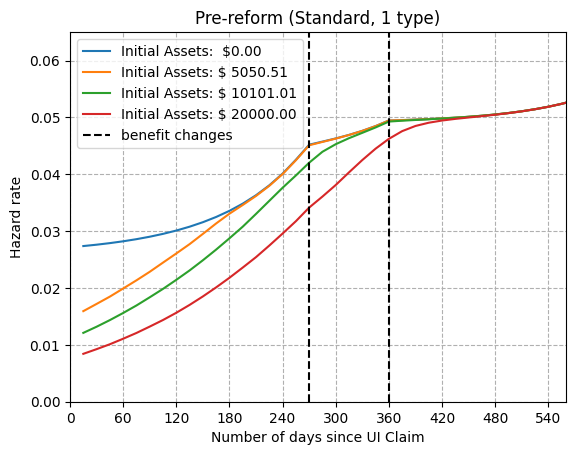

In [55]:
plt.plot(timevec_std, search[0,:], label=f"Initial Assets:  ${asset_grid[0]:.2f}")
plt.plot(timevec_std, search[25,:], label=f"Initial Assets: $ {asset_grid[25]:.2f}")
plt.plot(timevec_std, search[50,:], label=f"Initial Assets: $ {asset_grid[50]:.2f}")
plt.plot(timevec_std, search[99,:], label=f"Initial Assets: $ {asset_grid[99]:.2f}")

plt.xlabel('Number of days since UI Claim')
plt.xlim(0, 560) # set x-axis limits to first and last element in timevec
plt.ylim(0, 0.065) # set y-axis limits
plt.gca().xaxis.set_major_locator(plt.MaxNLocator(11))  # at most 8 ticks
plt.ylabel('Hazard rate')
plt.title('Pre-reform (Standard, 1 type)')
plt.vlines(x=[ T2*15, T3*15], ymin=0, ymax=0.065, colors='black', linestyles='dashed', label='benefit changes')
plt.legend()
plt.grid(True, linestyle='--')
plt.savefig('/Users/jacobaspnissen/Desktop/Økonomi/Dynamic programming/Termpaper/termpaper_dynprog/Figurer/HR pre st.pdf', bbox_inches='tight')
plt.show()

In [42]:
htm = 0

In [46]:
C_st, S_st, surv_st, A_st, A_grid_st, benefits = model.SolveForward(params_st, institutions_pre, abar, htm)
timevec_st = np.arange(S_st.shape[1])*15 + 15

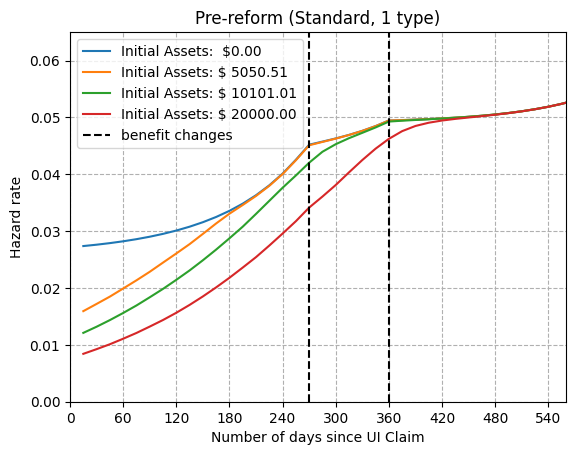

In [48]:
plt.plot(timevec_st, S_st[0,:], label=f"Initial Assets:  ${A_grid_st[0]:.2f}")
plt.plot(timevec_st, S_st[25,:], label=f"Initial Assets: $ {A_grid_st[25]:.2f}")
plt.plot(timevec_st, S_st[50,:], label=f"Initial Assets: $ {A_grid_st[50]:.2f}")
plt.plot(timevec_st, S_st[99,:], label=f"Initial Assets: $ {A_grid_st[99]:.2f}")

plt.xlabel('Number of days since UI Claim')
plt.xlim(0, 560) # set x-axis limits to first and last element in timevec
plt.ylim(0, 0.065) # set y-axis limits
plt.gca().xaxis.set_major_locator(plt.MaxNLocator(11))  # at most 8 ticks
plt.ylabel('Hazard rate')
plt.title('Pre-reform (Standard, 1 type)')
plt.vlines(x=[ T2*15, T3*15], ymin=0, ymax=0.065, colors='black', linestyles='dashed', label='benefit changes')
plt.legend()
plt.grid(True, linestyle='--')
plt.savefig('/Users/jacobaspnissen/Desktop/Økonomi/Dynamic programming/Termpaper/termpaper_dynprog/Figurer/HR pre st.pdf', bbox_inches='tight')
plt.show()

In [53]:
surv_st

array([[1.        , 0.97262391, 0.94576425, ..., 0.15700202, 0.14784511,
        0.13896048],
       [1.        , 0.973238  , 0.94661771, ..., 0.15717572, 0.14800868,
        0.13911422],
       [1.        , 0.9742131 , 0.94804012, ..., 0.15747186, 0.14828755,
        0.13937633],
       ...,
       [1.        , 0.99147747, 0.98220906, ..., 0.21110419, 0.19879188,
        0.18684565],
       [1.        , 0.99152733, 0.98230999, ..., 0.21154209, 0.19920424,
        0.18723323],
       [1.        , 0.99157692, 0.98240963, ..., 0.21190183, 0.199543  ,
        0.18755164]], shape=(100, 45))

In [54]:
timevec_st = np.arange(surv_st.shape[1])*15

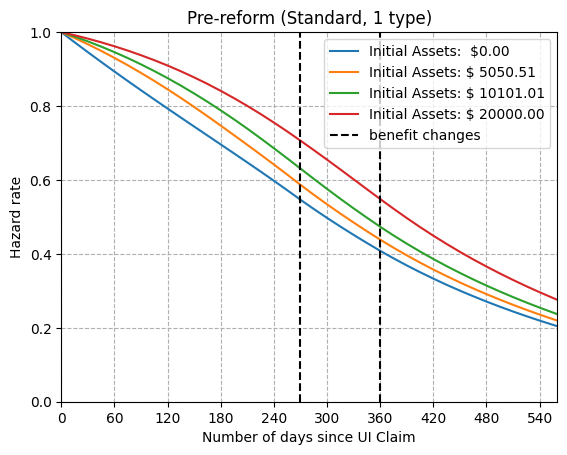

In [58]:
plt.plot(timevec_st, surv_st[0,:], label=f"Initial Assets:  ${A_grid_st[0]:.2f}")
plt.plot(timevec_st, surv_st[25,:], label=f"Initial Assets: $ {A_grid_st[25]:.2f}")
plt.plot(timevec_st, surv_st[50,:], label=f"Initial Assets: $ {A_grid_st[50]:.2f}")
plt.plot(timevec_st, surv_st[99,:], label=f"Initial Assets: $ {A_grid_st[99]:.2f}")

plt.xlabel('Number of days since UI Claim')
plt.xlim(0, 560) # set x-axis limits to first and last element in timevec
plt.ylim(0, 1) # set y-axis limits
plt.gca().xaxis.set_major_locator(plt.MaxNLocator(11))  # at most 8 ticks
plt.ylabel('Hazard rate')
plt.title('Pre-reform (Standard, 1 type)')
plt.vlines(x=[ T2*15, T3*15], ymin=0, ymax=1, colors='black', linestyles='dashed', label='benefit changes')
plt.legend()
plt.grid(True, linestyle='--')
plt.savefig('/Users/jacobaspnissen/Desktop/Økonomi/Dynamic programming/Termpaper/termpaper_dynprog/Figurer/HR pre st.pdf', bbox_inches='tight')
plt.show()

In [66]:
timevec_st = np.arange(C_st.shape[1])*15 + 15

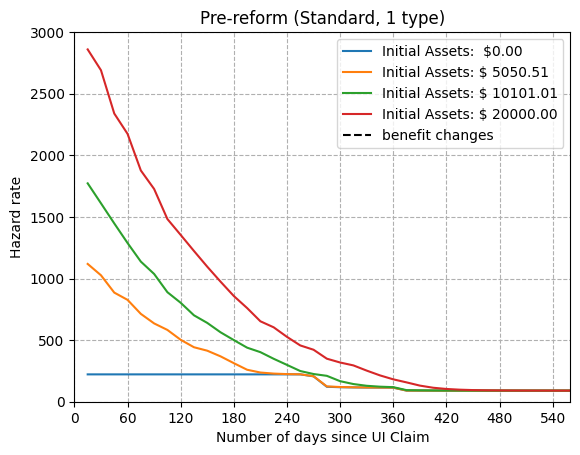

In [67]:
plt.plot(timevec_st, C_st[0,:], label=f"Initial Assets:  ${A_grid_st[0]:.2f}")
plt.plot(timevec_st, C_st[25,:], label=f"Initial Assets: $ {A_grid_st[25]:.2f}")
plt.plot(timevec_st, C_st[50,:], label=f"Initial Assets: $ {A_grid_st[50]:.2f}")
plt.plot(timevec_st, C_st[99,:], label=f"Initial Assets: $ {A_grid_st[99]:.2f}")

plt.xlabel('Number of days since UI Claim')
plt.xlim(0, 560) # set x-axis limits to first and last element in timevec
plt.ylim(0, 3000) # set y-axis limits
plt.gca().xaxis.set_major_locator(plt.MaxNLocator(11))  # at most 8 ticks
plt.ylabel('Hazard rate')
plt.title('Pre-reform (Standard, 1 type)')
plt.vlines(x=[ T2*15, T3*15], ymin=0, ymax=0.065, colors='black', linestyles='dashed', label='benefit changes')
plt.legend()
plt.grid(True, linestyle='--')
plt.savefig('/Users/jacobaspnissen/Desktop/Økonomi/Dynamic programming/Termpaper/termpaper_dynprog/Figurer/HR pre st.pdf', bbox_inches='tight')
plt.show()

In [57]:
benefits

array([222., 222., 222., 222., 222., 222., 222., 222., 222., 222., 222.,
       222., 222., 222., 222., 222., 222., 222., 114., 114., 114., 114.,
       114., 114.,  90.,  90.,  90.,  90.,  90.,  90.,  90.,  90.,  90.,
        90.,  90.,  90.,  90.,  90.,  90.,  90.,  90.,  90.,  90.,  90.])

In [60]:
cons_agg_st, s_agg_st, assets_agg_st, asset_grid_out_st, benefits_out_st = model.SolveMultiTypeModel(params_multi, institutions_pre, abar, htm)
timevec_st = np.arange(s_agg_st.shape[1])*15 + 15

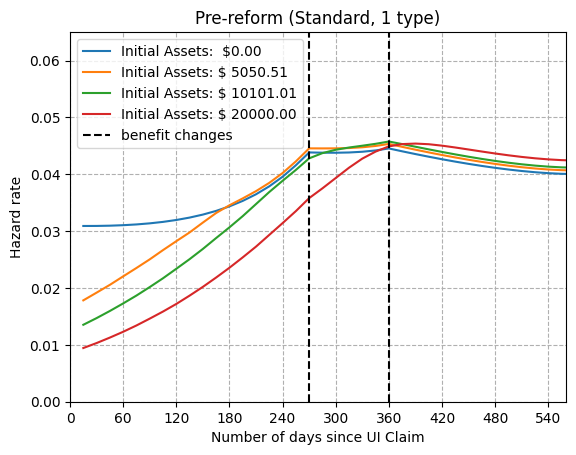

In [61]:
plt.plot(timevec_st, s_agg_st[0,:], label=f"Initial Assets:  ${A_grid_st[0]:.2f}")
plt.plot(timevec_st, s_agg_st[25,:], label=f"Initial Assets: $ {A_grid_st[25]:.2f}")
plt.plot(timevec_st, s_agg_st[50,:], label=f"Initial Assets: $ {A_grid_st[50]:.2f}")
plt.plot(timevec_st, s_agg_st[99,:], label=f"Initial Assets: $ {A_grid_st[99]:.2f}")

plt.xlabel('Number of days since UI Claim')
plt.xlim(0, 560) # set x-axis limits to first and last element in timevec
plt.ylim(0, 0.065) # set y-axis limits
plt.gca().xaxis.set_major_locator(plt.MaxNLocator(11))  # at most 8 ticks
plt.ylabel('Hazard rate')
plt.title('Pre-reform (Standard, 1 type)')
plt.vlines(x=[ T2*15, T3*15], ymin=0, ymax=0.065, colors='black', linestyles='dashed', label='benefit changes')
plt.legend()
plt.grid(True, linestyle='--')
plt.savefig('/Users/jacobaspnissen/Desktop/Økonomi/Dynamic programming/Termpaper/termpaper_dynprog/Figurer/HR pre st.pdf', bbox_inches='tight')
plt.show()

In [62]:
timevec_st = np.arange(cons_agg_st.shape[1])*15 + 15

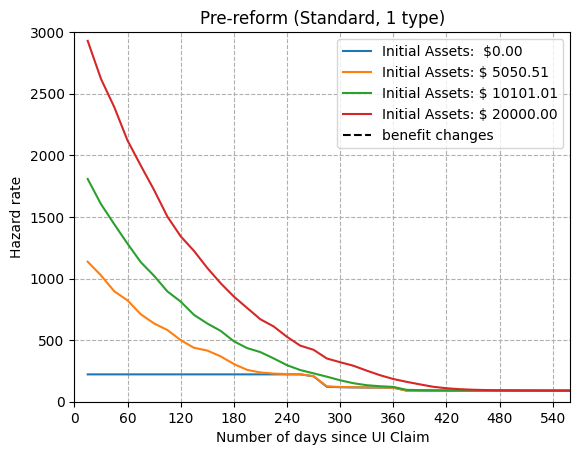

In [65]:
plt.plot(timevec_st, cons_agg_st[0,:], label=f"Initial Assets:  ${A_grid_st[0]:.2f}")
plt.plot(timevec_st, cons_agg_st[25,:], label=f"Initial Assets: $ {A_grid_st[25]:.2f}")
plt.plot(timevec_st, cons_agg_st[50,:], label=f"Initial Assets: $ {A_grid_st[50]:.2f}")
plt.plot(timevec_st, cons_agg_st[99,:], label=f"Initial Assets: $ {A_grid_st[99]:.2f}")

plt.xlabel('Number of days since UI Claim')
plt.xlim(0, 560) # set x-axis limits to first and last element in timevec
plt.ylim(0, 3000) # set y-axis limits
plt.gca().xaxis.set_major_locator(plt.MaxNLocator(11))  # at most 8 ticks
plt.ylabel('Hazard rate')
plt.title('Pre-reform (Standard, 1 type)')
plt.vlines(x=[ T2*15, T3*15], ymin=0, ymax=0.065, colors='black', linestyles='dashed', label='benefit changes')
plt.legend()
plt.grid(True, linestyle='--')
plt.savefig('/Users/jacobaspnissen/Desktop/Økonomi/Dynamic programming/Termpaper/termpaper_dynprog/Figurer/HR pre st.pdf', bbox_inches='tight')
plt.show()

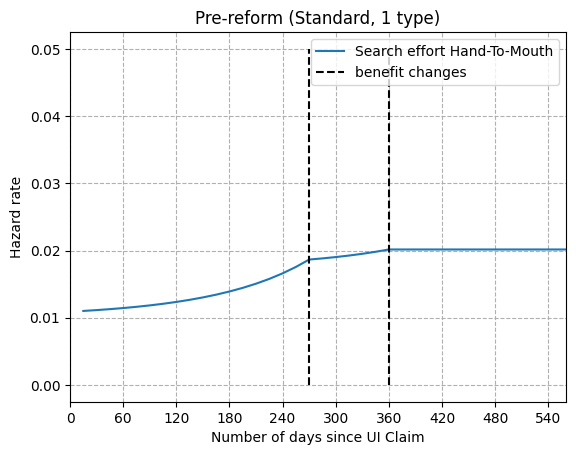

In [109]:

plt.plot(timevec_std, S_std_pre[0,:-1], label="Search effort Hand-To-Mouth")

plt.xlabel('Number of days since UI Claim')
plt.xlim(0, 560) # set x-axis limits to first and last element in timevec
plt.gca().xaxis.set_major_locator(plt.MaxNLocator(11))  # at most 8 ticks
plt.ylabel('Hazard rate')
plt.title('Pre-reform (Standard, 1 type)')
plt.vlines(x=[ T2*15, T3*15], ymin=0, ymax=0.05, colors='black', linestyles='dashed', label='benefit changes')
plt.legend()
plt.grid(True, linestyle='--')
plt.savefig('/Users/jacobaspnissen/Desktop/Økonomi/Dynamic programming/Termpaper/termpaper_dynprog/Figurer/HR pre st.pdf', bbox_inches='tight')
plt.show()

In [110]:
S_std_pre2t, V_emp_std_pre2t, V_unemp_std_pre2t, c_emp_std_pre2t, c_unemp_std_pre2t, Vss_emp_std_pre2t, Vss_uemp_std_pre2t, css_emp_std_pre2t, css_uemp_std_pre2t, survival_std_pre2t, benefits_std_pre2t = model.SolveMultiTypeModel(params_twotype, institutions_pre, abar, htm)
timevec_std = np.arange((len(S_std_pre2t[0,:-1])))*15 +15

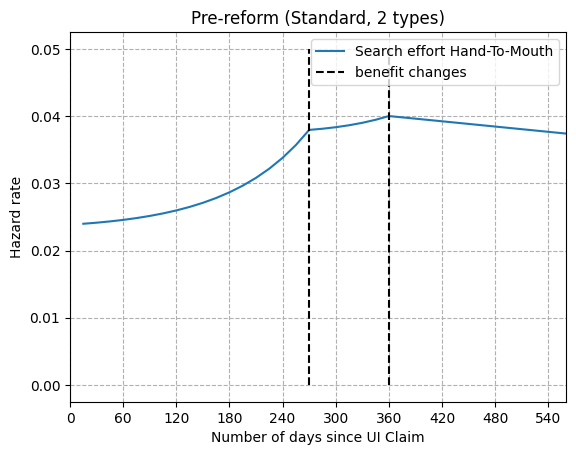

In [111]:
plt.plot(timevec_std, S_std_pre2t[0,:-1], label="Search effort Hand-To-Mouth")

plt.xlabel('Number of days since UI Claim')
plt.xlim(0, 560) # set x-axis limits to first and last element in timevec
plt.gca().xaxis.set_major_locator(plt.MaxNLocator(11))  # at most 8 ticks
plt.ylabel('Hazard rate')
plt.title('Pre-reform (Standard, 2 types)')
plt.vlines(x=[ T2*15, T3*15], ymin=0, ymax=0.05, colors='black', linestyles='dashed', label='benefit changes')
plt.legend()
plt.grid(True, linestyle='--')
plt.savefig('/Users/jacobaspnissen/Desktop/Økonomi/Dynamic programming/Termpaper/termpaper_dynprog/Figurer/HR pre 2t.pdf', bbox_inches='tight')
plt.show()

In [112]:
S_std_pre3t, V_emp_std_pre3t, V_unemp_std_pre3t, c_emp_std_pre3t, c_unemp_std_pre3t, Vss_emp_std_pre3t, Vss_uemp_std_pre3t, css_emp_std_pre3t, css_uemp_std_pre3t, survival_std_pre3t, benefits_std_pre3t = model.SolveMultiTypeModel(params_multi, institutions_pre, abar, htm)
timevec_std = np.arange((len(S_std_pre3t[0,:-1])))*15 +15

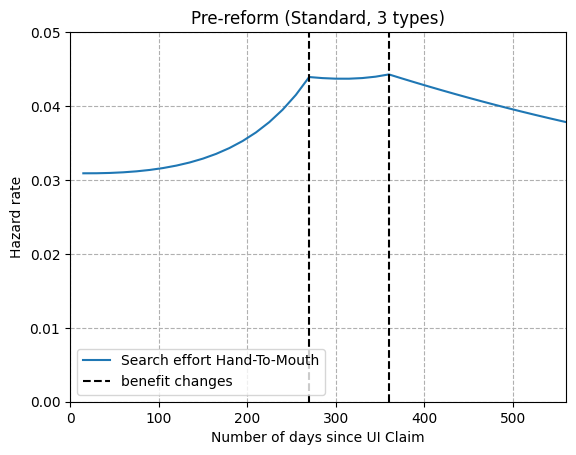

In [113]:
plt.plot(timevec_std, S_std_pre3t[0,:-1], label="Search effort Hand-To-Mouth")

plt.xlabel('Number of days since UI Claim')
plt.xlim(0, 560) # set x-axis limits to first and last element in timevec
plt.ylim(0, 0.05) # set y-axis limits to first and last element in timevec
#plt.gca().xaxis.set_major_locator(plt.MaxNLocator(11))  # at most 8 ticks
plt.ylabel('Hazard rate')
plt.title('Pre-reform (Standard, 3 types)')
plt.vlines(x=[ T2*15, T3*15], ymin=0, ymax=0.05, colors='black', linestyles='dashed', label='benefit changes')
plt.legend()
plt.grid(True, linestyle='--')
plt.savefig('/Users/jacobaspnissen/Desktop/Økonomi/Dynamic programming/Termpaper/termpaper_dynprog/Figurer/HR pre 3t.pdf', bbox_inches='tight')
plt.show()

## Predict standard Model on Post-reform institutions
First we predict using 1 types, then followed by 2 types and 3 types

In [114]:
S_std_post, V_emp_std_post, V_unemp_std_post, c_emp_std_post, c_unemp_std_post, Vss_emp_std_post, Vss_uemp_std_post, css_emp_std_post, css_uemp_std_post, survival_std, benefits_std = model.SolveModel(params_st, institutions_post, abar, htm)
timevec_std = np.arange((len(S_std_post[0,:-1])))*15 +15

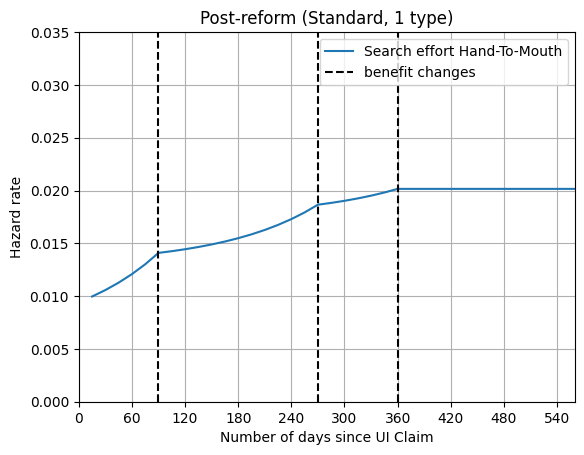

In [115]:
plt.plot(timevec_std, S_std_post[0,:-1], label="Search effort Hand-To-Mouth")

plt.xlabel('Number of days since UI Claim')
plt.xlim(0, 560) # set x-axis limits to first and last element in timevec
plt.ylim(0, 0.035) # set y-axis limits to first and last element in timevec
plt.gca().xaxis.set_major_locator(plt.MaxNLocator(11))  # at most 8 ticks
plt.ylabel('Hazard rate')
plt.title('Post-reform (Standard, 1 type)')
plt.vlines(x=[T1*15, T2*15, T3*15], ymin=0, ymax=0.035, colors='black', linestyles='dashed', label='benefit changes')
plt.legend()
plt.grid(True)
plt.show()

In [116]:
S_std_post2t, V_emp_std_post2t, V_unemp_std_post2t, c_emp_std_post2t, c_unemp_std_post2t, Vss_emp_std_post2t, Vss_uemp_std_post2t, css_emp_std_post2t, css_uemp_std_post2t, survival_std, benefits_std = model.SolveMultiTypeModel(params_twotype, institutions_post, abar, htm)
timevec_std = np.arange((len(S_std_post2t[0,:-1])))*15+15

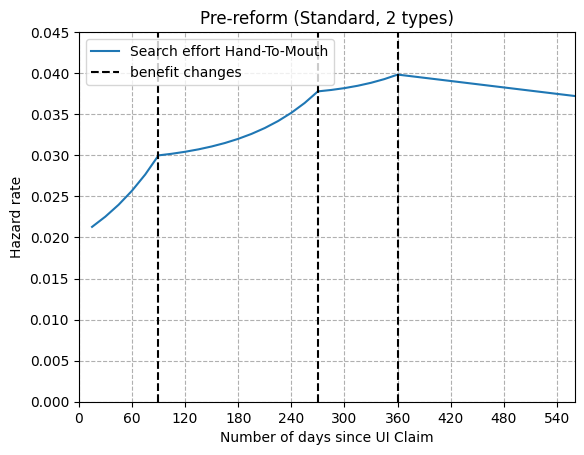

In [117]:
plt.plot(timevec_std, S_std_post2t[0,:-1], label="Search effort Hand-To-Mouth")

plt.xlabel('Number of days since UI Claim')
plt.xlim(0, 560) # set x-axis limits to first and last element in timevec
plt.ylim(0, 0.045) # set y-axis limits to first and last element in timevec
plt.gca().xaxis.set_major_locator(plt.MaxNLocator(11))  # at most 8 ticks
plt.ylabel('Hazard rate')
plt.title('Pre-reform (Standard, 2 types)')
plt.vlines(x=[T1*15, T2*15, T3*15], ymin=0, ymax=0.045, colors='black', linestyles='dashed', label='benefit changes')
plt.legend()
plt.grid(True, linestyle='--')
plt.savefig('/Users/jacobaspnissen/Desktop/Økonomi/Dynamic programming/Termpaper/termpaper_dynprog/Figurer/HR post 2t.pdf', bbox_inches='tight')
plt.show()

In [118]:
S_std_post3t, V_emp_std_post3t, V_unemp_std_post3t, c_emp_std_post3t, c_unemp_std_post3t, Vss_emp_std_post3t, Vss_uemp_std_post3t, css_emp_std_post3t, css_uemp_std_post3t, survival_std, benefits_std = model.SolveMultiTypeModel(params_multi, institutions_post, abar, htm)
timevec_std = np.arange((len(S_std_post3t[0,:-1])))*15 +15

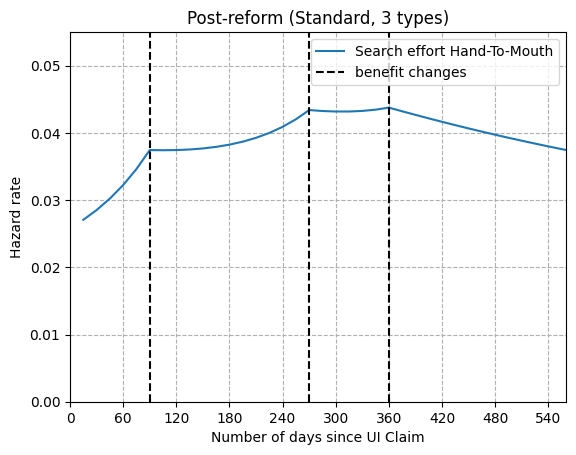

In [119]:
plt.plot(timevec_std, S_std_post3t[0,:-1], label="Search effort Hand-To-Mouth")

plt.xlabel('Number of days since UI Claim')
plt.xlim(0, 560) # set x-axis limits to first and last element in timevec
plt.ylim(0, 0.055) # set y-axis limits to first and last element in timevec
plt.gca().xaxis.set_major_locator(plt.MaxNLocator(11))  # at most 8 ticks
plt.ylabel('Hazard rate')
plt.title('Post-reform (Standard, 3 types)')
plt.vlines(x=[T1*15, T2*15, T3*15], ymin=0, ymax=0.55, colors='black', linestyles='dashed', label='benefit changes')
plt.legend()
plt.grid(True, linestyle='--')
plt.savefig('/Users/jacobaspnissen/Desktop/Økonomi/Dynamic programming/Termpaper/termpaper_dynprog/Figurer/HR post 3t.pdf', bbox_inches='tight')
plt.show()

## Predict the reference dependent model on pre-reform institutions


In [124]:
htm = 0
weights = model.make_weights(htm, abar, n_a)

In [125]:
S_rd, V_emp_rd, V_unemp_rd, c_emp_rd, c_unemp_rd, Vss_emp_rd, Vss_uemp_rd, css_emp_rd, css_uemp_rd, survival_rd, benefits_rd = model.SolveModel(params_rd, institutions_pre, abar, htm)
timevec_rd = np.arange((len(S_rd[0,:-1])))*15


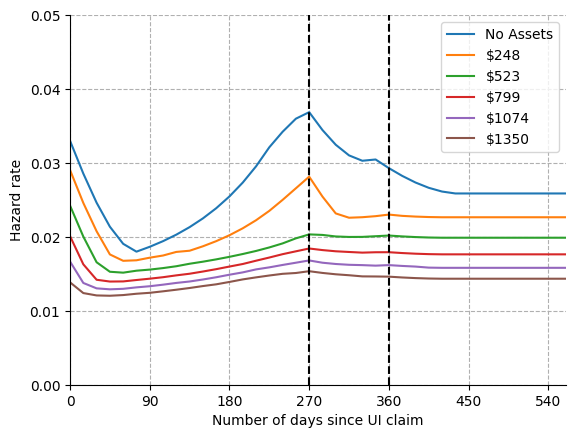

In [126]:

plt.figure(figsize=(6.4, 4.8))

plt.plot(timevec_rd, S_rd[0, :-1], label="No Assets")
plt.plot(timevec_rd, S_rd[9, :-1], label="$248")
plt.plot(timevec_rd, S_rd[19, :-1], label="$523")
plt.plot(timevec_rd, S_rd[29, :-1], label="$799")
plt.plot(timevec_rd, S_rd[39, :-1], label="$1074")
plt.plot(timevec_rd, S_rd[49, :-1], label="$1350")

plt.xlabel('Number of days since UI claim')
plt.ylabel('Hazard rate')
#plt.title('Pre-reform Hazard Rates for Hungary')

# X-axis: same range as your original graph
plt.xlim(0, 560)
plt.xticks(np.arange(0, 541, 90))


# Y-axis: start at zero, let the upper limit be automatic
plt.ylim(bottom=0)
plt.yticks(np.arange(0, 0.06, 0.01))

# Vertical lines for benefit changes
plt.vlines(
    x=[T2 * 15, T3 * 15],
    ymin=0,
    ymax=0.05,
    colors='black',
    linestyles='dashed'
)

# Remove top and right frame
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.grid(True, linestyle='--')
plt.legend()
#plt.savefig('/Users/albertolsen/Documents/Stud Polit/9. semester/Dynamic Programming/Exam/termpaper_dynprog/Figurer/HR pre.pdf', bbox_inches='tight')
plt.savefig('/Users/jacobaspnissen/Desktop/Økonomi/Dynamic programming/Termpaper/termpaper_dynprog/Figurer/HR pre.pdf', bbox_inches='tight')
plt.show()

### Value of Employment and Unemployment Pre-reform

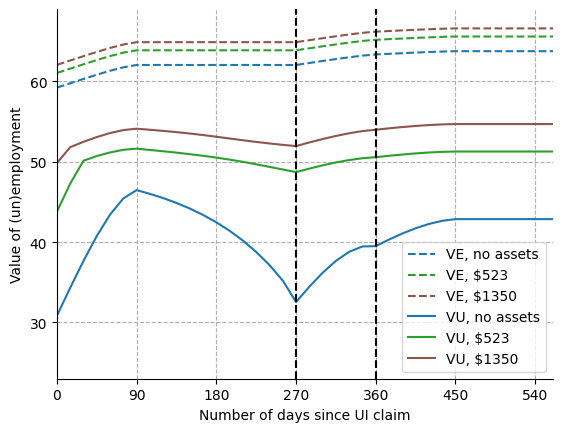

In [128]:
plt.figure(figsize=(6.4, 4.8))

plt.plot(timevec_rd, V_emp_rd[0, :-1], label="VE, no assets", linestyle='dashed', color='tab:blue')
plt.plot(timevec_rd, V_emp_rd[29, :-1], label="VE, $523", linestyle='dashed', color='tab:green')
plt.plot(timevec_rd, V_emp_rd[49, :-1], label="VE, $1350", linestyle='dashed', color='tab:brown')

plt.plot(timevec_rd, V_unemp_rd[0, :-1], label="VU, no assets", color='tab:blue')
plt.plot(timevec_rd, V_unemp_rd[29, :-1], label="VU, $523", color='tab:green')
plt.plot(timevec_rd, V_unemp_rd[49, :-1], label="VU, $1350", color='tab:brown')

plt.xlabel('Number of days since UI claim')
plt.ylabel('Value of (un)employment')
#plt.title('Post-reform Hazard Rates for Hungary')

# X-axis
plt.xlim(0, 560)
plt.xticks(np.arange(0, 541, 90))

# Y-axis
plt.ylim(bottom=23)
plt.ylim(top=69)
#plt.yticks(np.arange(0, 0.06, 0.01))

# Vertical lines for benefit changes
plt.vlines(
    x=[T2 * 15, T3 * 15],
    ymin=23,
    ymax=69,
    colors='black',
    linestyles='dashed'
)

# Remove top and right frame
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.grid(True, linestyle='--')
plt.legend(loc ='lower right')

plt.savefig('/Users/jacobaspnissen/Desktop/Økonomi/Dynamic programming/Termpaper/termpaper_dynprog/Figurer/VE,VU pre.pdf', bbox_inches='tight')


plt.show()

## Predict the reference dependent model on post-reform institutions

In [131]:
S_rd_post, V_emp_rd_post, V_unemp_rd_post, c_emp_rd_post, c_unemp_rd_post, Vss_emp_rd_post, Vss_uemp_rd_post, css_emp_rd_post, css_uemp_rd_post, survival_rd_post, benefits_rd_post = model.SolveModel(params_rd, institutions_post, abar, htm)
timevec_rd_post = np.arange((len(S_rd[0,:-1])))*15

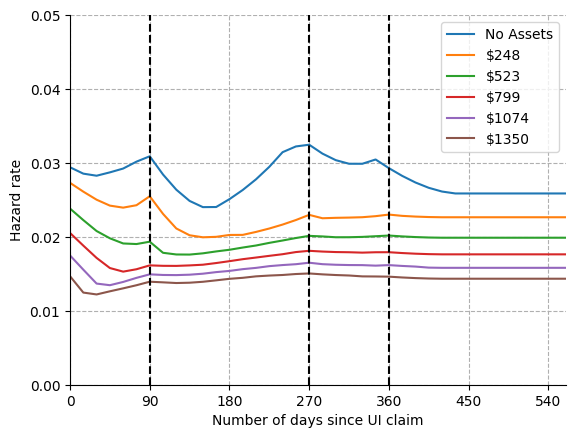

In [133]:
plt.figure(figsize=(6.4, 4.8))

plt.plot(timevec_rd_post, S_rd_post[0, :-1], label="No Assets")
plt.plot(timevec_rd_post, S_rd_post[9, :-1], label="$248")
plt.plot(timevec_rd_post, S_rd_post[19, :-1], label="$523")
plt.plot(timevec_rd_post, S_rd_post[29, :-1], label="$799")
plt.plot(timevec_rd_post, S_rd_post[39, :-1], label="$1074")
plt.plot(timevec_rd_post, S_rd_post[49, :-1], label="$1350")

plt.xlabel('Number of days since UI claim')
plt.ylabel('Hazard rate')
#plt.title('Post-reform Hazard Rates for Hungary')

# X-axis
plt.xlim(0, 560)
plt.xticks(np.arange(0, 541, 90))

# Y-axis: start at zero, same ticks as the final graph
plt.ylim(bottom=0)
plt.yticks(np.arange(0, 0.06, 0.01))

# Vertical lines for benefit changes
plt.vlines(
    x=[T1 * 15, T2 * 15, T3 * 15],
    ymin=0,
    ymax=0.05,
    colors='black',
    linestyles='dashed'
)

# Remove top and right frame
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.legend()
plt.grid(True, linestyle='--')

plt.savefig('/Users/jacobaspnissen/Desktop/Økonomi/Dynamic programming/Termpaper/termpaper_dynprog/Figurer/HR post.pdf', bbox_inches='tight')

plt.show()

### We plot value of unemployment for the post reform against value of employment. 

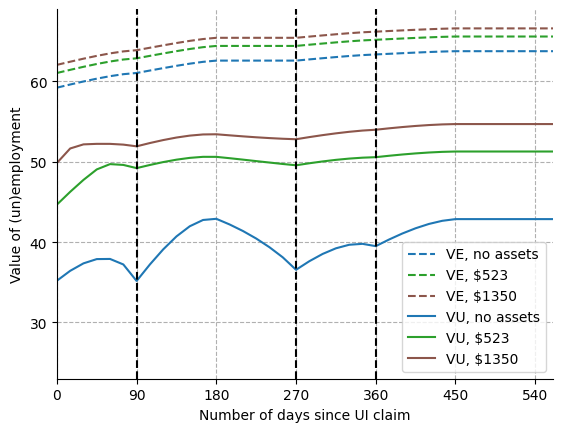

In [134]:
plt.figure(figsize=(6.4, 4.8))

plt.plot(timevec_rd_post, V_emp_rd_post[0, :-1], label="VE, no assets", linestyle='dashed', color='tab:blue')
plt.plot(timevec_rd_post, V_emp_rd_post[29, :-1], label="VE, $523", linestyle='dashed', color='tab:green')
plt.plot(timevec_rd_post, V_emp_rd_post[49, :-1], label="VE, $1350", linestyle='dashed', color='tab:brown')

plt.plot(timevec_rd_post, V_unemp_rd_post[0, :-1], label="VU, no assets", color='tab:blue')
plt.plot(timevec_rd_post, V_unemp_rd_post[29, :-1], label="VU, $523", color='tab:green')
plt.plot(timevec_rd_post, V_unemp_rd_post[49, :-1], label="VU, $1350", color='tab:brown')

plt.xlabel('Number of days since UI claim')
plt.ylabel('Value of (un)employment')
#plt.title('Post-reform Hazard Rates for Hungary')

# X-axis
plt.xlim(0, 560)
plt.xticks(np.arange(0, 541, 90))

# Y-axis
plt.ylim(bottom=23)
plt.ylim(top=69)
#plt.yticks(np.arange(0, 0.06, 0.01))

# Vertical lines for benefit changes
plt.vlines(
    x=[T1 * 15, T2 * 15, T3 * 15],
    ymin=23,
    ymax=69,
    colors='black',
    linestyles='dashed'
)

# Remove top and right frame
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.legend(loc ='lower right')
plt.grid(True, linestyle='--')

plt.savefig('/Users/jacobaspnissen/Desktop/Økonomi/Dynamic programming/Termpaper/termpaper_dynprog/Figurer/VE,VU post.pdf', bbox_inches='tight')


plt.show()

### Here we plot the consumption path for the unemployed in the referent dependent model for different asset levels. 

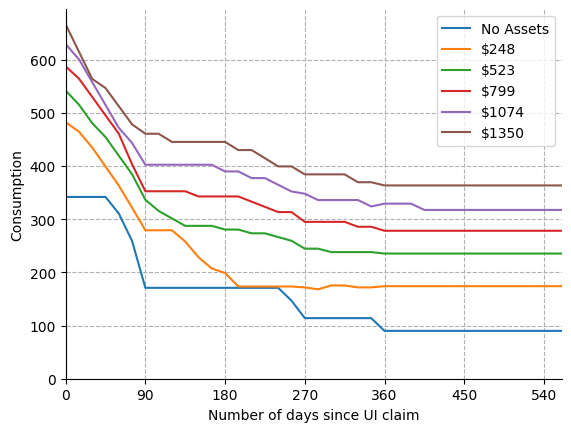

In [135]:
import numpy as np
import matplotlib.pyplot as plt

plt.figure(figsize=(6.4, 4.8))

plt.plot(timevec_rd_post, c_unemp_rd_post[0, :-1], label="No Assets")
plt.plot(timevec_rd_post, c_unemp_rd_post[9, :-1], label="$248")
plt.plot(timevec_rd_post, c_unemp_rd_post[19, :-1], label="$523")
plt.plot(timevec_rd_post, c_unemp_rd_post[29, :-1], label="$799")
plt.plot(timevec_rd_post, c_unemp_rd_post[39, :-1], label="$1074")
plt.plot(timevec_rd_post, c_unemp_rd_post[49, :-1], label="$1350")

plt.xlabel('Number of days since UI claim')
plt.ylabel('Consumption')
#plt.title('Post-reform Hazard Rates for Hungary')

# X-axis
plt.xlim(0, 560)
plt.xticks(np.arange(0, 541, 90))

# Y-axis: start at zero, same ticks as the final graph
plt.ylim(bottom=0)
#plt.yticks(np.arange(0, 0.06, 0.01))

# Vertical lines for benefit changes
plt.vlines(
    x=[T1 * 15, T2 * 15, T3 * 15],
    ymin=0,
    ymax=0.05,
    colors='black',
    linestyles='dashed'
)

# Remove top and right frame
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.legend()
plt.grid(True, linestyle='--')

plt.savefig('/Users/jacobaspnissen/Desktop/Økonomi/Dynamic programming/Termpaper/termpaper_dynprog/Figurer/Consumption post.pdf', bbox_inches='tight')

plt.show()